# Sid — Historical Regression Models

Predicting 2024 county-level Democratic vote share
using historical voting features + demographic features.

**Input:** `../data/processed/historical_merged_dataset.csv`
**Target:** `dem_share_2024`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

### (2) Load dataset

In [2]:
df = pd.read_csv(
    "../data/processed/historical_merged_dataset.csv",
    dtype={"county_fips": str},
    low_memory=False
)

print(f"Shape: {df.shape}")
print(f"\n2024 dem vote share stats:")
print(df["dem_share_2024"].describe().round(3))

Shape: (3113, 45)

2024 dem vote share stats:
count    3113.000
mean        0.316
std         0.155
min         0.035
25%         0.196
50%         0.283
75%         0.405
max         0.903
Name: dem_share_2024, dtype: float64


### (3) Feature sets

In [3]:
hist_features = [
    "dem_share_2000", "dem_share_2004", "dem_share_2008",
    "dem_share_2012", "dem_share_2016", "dem_share_2020",
    "winner_2000", "winner_2004", "winner_2008",
    "winner_2012", "winner_2016", "winner_2020",
    "dem_wins_count", "avg_dem_share", "dem_share_trend",
    "momentum_2016_2020", "momentum_2012_2016",
    "vote_volatility", "competitive_count"
]

demo_features = [
    "higher_ed_rate", "poverty_rate", "unemployment_rate",
    "white_pct", "black_pct", "asian_pct",
    "median_income", "log_population", "housing_density"
]

interaction_features = [
    "edu_x_trend", "white_x_momentum",
    "income_x_volatility", "edu_x_wins"
]

all_features = hist_features + demo_features + interaction_features
target       = "dem_share_2024"

model_df = df[all_features + [target]].dropna()
print(f"Rows: {len(model_df)} | Features: {len(all_features)}")

Rows: 3112 | Features: 32


### (4) Train/test split and scaling

In [5]:
X = model_df[all_features]
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Target range: {y.min():.3f} to {y.max():.3f}")
print(f"Target mean:  {y.mean():.3f}")

Train: (2489, 32) | Test: (623, 32)
Target range: 0.035 to 0.903
Target mean:  0.316


### (5) Train all models

In [6]:
def evaluate(name, y_test, y_pred):
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)
    print(f"{name}: R²={r2:.4f} | RMSE={rmse:.4f} | MAE={mae:.4f}")
    return {"Model": name, "R²": round(r2,4),
            "RMSE": round(rmse,4), "MAE": round(mae,4)}

models = {
    "Linear Regression":    LinearRegression(),
    "Ridge":                Ridge(alpha=1.0),
    "Lasso":                Lasso(alpha=0.001),
    "Random Forest":        RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    "Gradient Boosting":    GradientBoostingRegressor(n_estimators=200, random_state=42),
    "XGBoost":              XGBRegressor(n_estimators=200, random_state=42,
                                         verbosity=0, eval_metric="rmse"),
}

results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    results.append(evaluate(name, y_test, y_pred))

results_df = pd.DataFrame(results).set_index("Model")
print("\nFull comparison:")
display(results_df)

Linear Regression: R²=0.9909 | RMSE=0.0149 | MAE=0.0106
Ridge: R²=0.9908 | RMSE=0.0149 | MAE=0.0106
Lasso: R²=0.9906 | RMSE=0.0151 | MAE=0.0109
Random Forest: R²=0.9905 | RMSE=0.0152 | MAE=0.0109
Gradient Boosting: R²=0.9912 | RMSE=0.0146 | MAE=0.0103
XGBoost: R²=0.9910 | RMSE=0.0148 | MAE=0.0104

Full comparison:


,R²,RMSE,MAE
Model,,,
Linear Regression,0.9909,0.0149,0.0106
Ridge,0.9908,0.0149,0.0106
Lasso,0.9906,0.0151,0.0109
Random Forest,0.9905,0.0152,0.0109
Gradient Boosting,0.9912,0.0146,0.0103
XGBoost,0.9910,0.0148,0.0104


### (6) Predicted vs Actual — best model

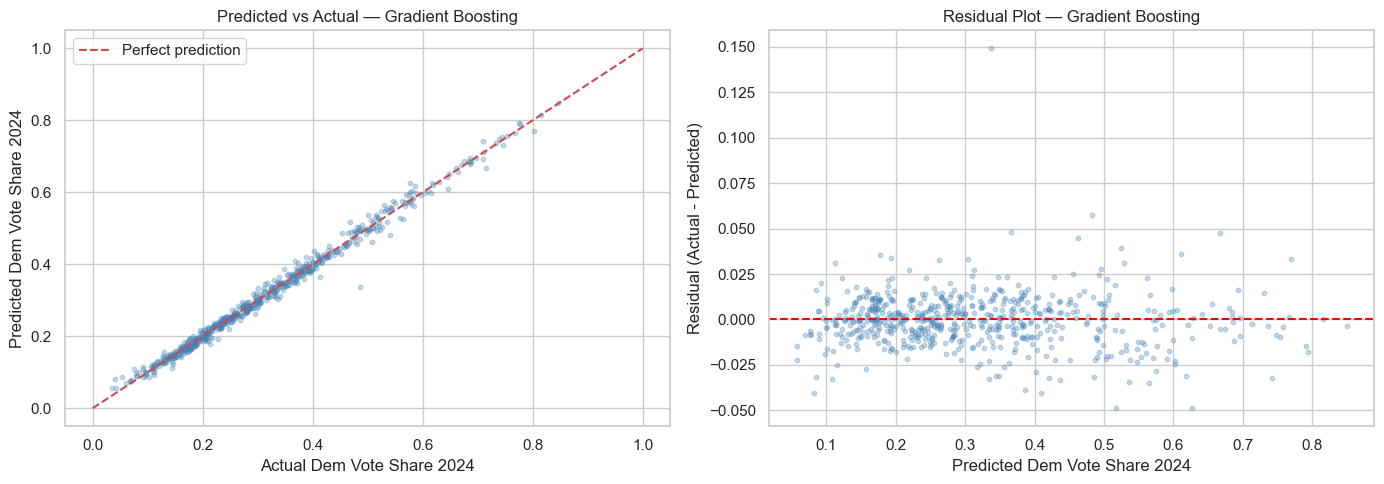

In [7]:
best_model = models["Gradient Boosting"]
y_pred_best = best_model.predict(X_test_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicted vs Actual
axes[0].scatter(y_test, y_pred_best, alpha=0.3, s=10, color="steelblue")
axes[0].plot([0,1],[0,1],"r--", linewidth=1.5, label="Perfect prediction")
axes[0].set_xlabel("Actual Dem Vote Share 2024")
axes[0].set_ylabel("Predicted Dem Vote Share 2024")
axes[0].set_title("Predicted vs Actual — Gradient Boosting")
axes[0].legend()

# Residuals
residuals = y_test - y_pred_best
axes[1].scatter(y_pred_best, residuals, alpha=0.3, s=10, color="steelblue")
axes[1].axhline(0, color="red", linestyle="--", linewidth=1.5)
axes[1].set_xlabel("Predicted Dem Vote Share 2024")
axes[1].set_ylabel("Residual (Actual - Predicted)")
axes[1].set_title("Residual Plot — Gradient Boosting")

plt.tight_layout()
plt.show()

### (7) Ablation — full vs demographics only

In [8]:
# Train on demographics only
X_demo_train = X_train[demo_features]
X_demo_test  = X_test[demo_features]

scaler_demo = StandardScaler()
X_demo_train_s = scaler_demo.fit_transform(X_demo_train)
X_demo_test_s  = scaler_demo.transform(X_demo_test)

rf_demo = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_demo.fit(X_demo_train_s, y_train)
y_pred_demo = rf_demo.predict(X_demo_test_s)

r2_demo   = r2_score(y_test, y_pred_demo)
rmse_demo = np.sqrt(mean_squared_error(y_test, y_pred_demo))

print("Ablation Study — Full Features vs Demographics Only:")
print("=" * 50)
print(f"{'Metric':<12} {'Full (GB)':<15} {'Demo Only (RF)':<15} {'Improvement'}")
print("-" * 50)
print(f"{'R²':<12} {0.9912:<15.4f} {r2_demo:<15.4f} {0.9912-r2_demo:+.4f}")
print(f"{'RMSE':<12} {0.0146:<15.4f} {rmse_demo:<15.4f} {rmse_demo-0.0146:+.4f}")

Ablation Study — Full Features vs Demographics Only:
Metric       Full (GB)       Demo Only (RF)  Improvement
--------------------------------------------------
R²           0.9912          0.7344          +0.2568
RMSE         0.0146          0.0803          +0.0657


### (8) Feature importance — top 20

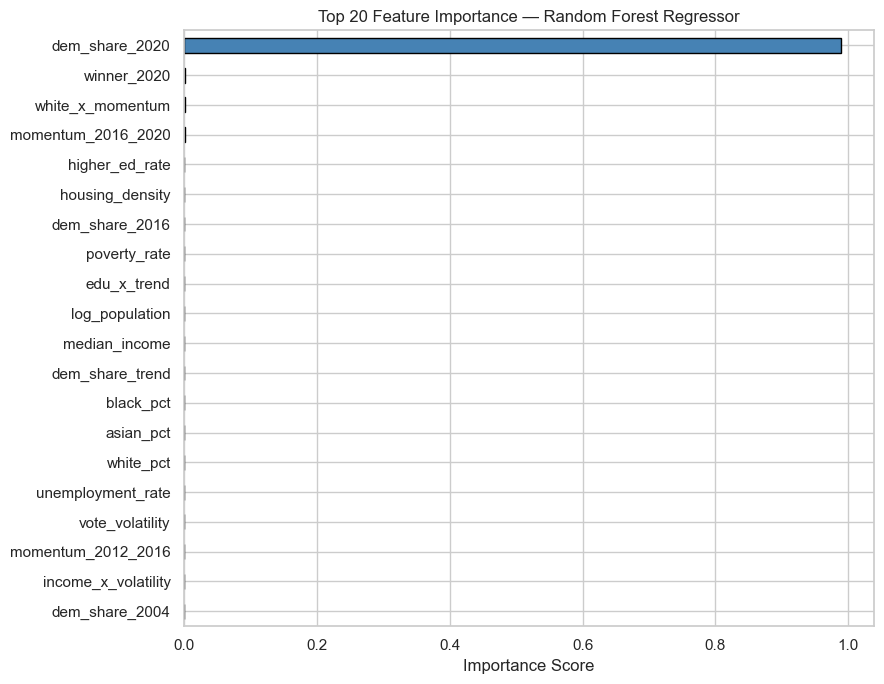


Top 20 features:
dem_share_2020         0.9891
winner_2020            0.0011
white_x_momentum       0.0011
momentum_2016_2020     0.0009
higher_ed_rate         0.0008
housing_density        0.0006
dem_share_2016         0.0005
poverty_rate           0.0005
edu_x_trend            0.0004
log_population         0.0004
median_income          0.0004
dem_share_trend        0.0004
black_pct              0.0004
asian_pct              0.0004
white_pct              0.0003
unemployment_rate      0.0003
vote_volatility        0.0003
momentum_2012_2016     0.0003
income_x_volatility    0.0003
dem_share_2004         0.0002
dtype: float64


In [9]:
rf_model = models["Random Forest"]

feat_imp = pd.Series(
    rf_model.feature_importances_,
    index=all_features
).sort_values(ascending=False).head(20)

plt.figure(figsize=(9, 7))
feat_imp.sort_values().plot(kind="barh", color="steelblue", edgecolor="black")
plt.title("Top 20 Feature Importance — Random Forest Regressor")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

print("\nTop 20 features:")
print(feat_imp.round(4))

### (9) All models comparison chart

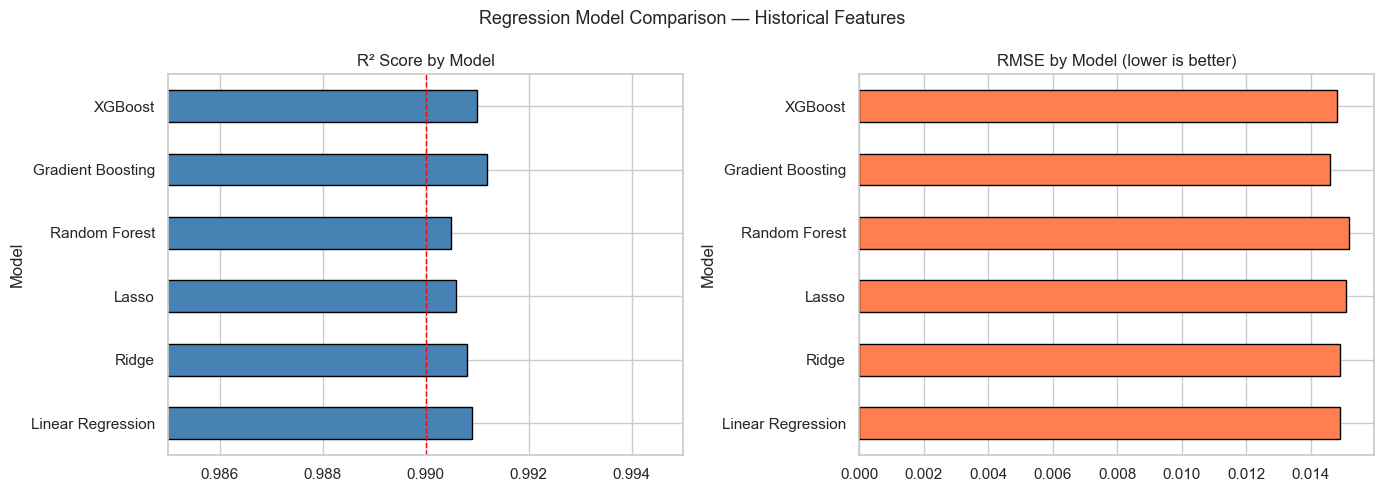

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

results_df["R²"].plot(kind="barh", ax=axes[0], color="steelblue",
                       edgecolor="black")
axes[0].set_title("R² Score by Model")
axes[0].set_xlim(0.985, 0.995)
axes[0].axvline(0.99, color="red", linestyle="--", linewidth=1)

results_df["RMSE"].plot(kind="barh", ax=axes[1], color="coral",
                         edgecolor="black")
axes[1].set_title("RMSE by Model (lower is better)")

plt.suptitle("Regression Model Comparison — Historical Features", fontsize=13)
plt.tight_layout()
plt.show()

### (10) Summary

In [11]:
best = results_df["R²"].idxmax()

print("=" * 55)
print("HISTORICAL REGRESSION SUMMARY")
print("=" * 55)
print(f"Training years:      2000–2020")
print(f"Test target:         2024 dem vote share")
print(f"Total features:      {len(all_features)}")
print(f"\nAll models R² > 0.99 — historical features make")
print(f"vote share prediction nearly perfect.")
print(f"\nBest model:          {best}")
print(f"R²:                  {results_df.loc[best,'R²']}")
print(f"RMSE:                {results_df.loc[best,'RMSE']}")
print(f"MAE:                 {results_df.loc[best,'MAE']}")
print(f"\nComparison vs 2020-only regression:")
print(f"  2020-only RF R²:   0.737")
print(f"  Historical GB R²:  0.991")
print(f"  Improvement:       +0.254")
print(f"\nKey insight: Adding historical voting features")
print(f"improved R² by +0.254 — from 0.737 to 0.991.")
print(f"Past voting behavior explains 99% of vote share.")
print("=" * 55)

HISTORICAL REGRESSION SUMMARY
Training years:      2000–2020
Test target:         2024 dem vote share
Total features:      32

All models R² > 0.99 — historical features make
vote share prediction nearly perfect.

Best model:          Gradient Boosting
R²:                  0.9912
RMSE:                0.0146
MAE:                 0.0103

Comparison vs 2020-only regression:
  2020-only RF R²:   0.737
  Historical GB R²:  0.991
  Improvement:       +0.254

Key insight: Adding historical voting features
improved R² by +0.254 — from 0.737 to 0.991.
Past voting behavior explains 99% of vote share.
